In [ ]:
## 本文件用于最初调试代码bug

In [1]:
import os
from glob import glob
import random
import numpy as np
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
from PIL import Image
from torch.utils.data import Dataset


class InpaintingData(Dataset):
    def __init__(self, args):
        super(Dataset, self).__init__()
        self.w , self.h = args.image_size,args.image_size
        self.mask_type = args.mask_type
        self.dir_image = args.dir_image
        self.dir_mask = args.dir_mask
        self.data_train = args.data_train
        self.mask_type = args.mask_type
        self.mask_names = ['l_brow','neck','u_lip','l_lip','eye_g','mouth','hat','ear_r','hair','r_eye','neck_l','r_brow','l_eye','l_ear','r_ear','cloth','nose']
        # image and mask
        self.image_path = []
        for ext in ["*.jpg", "*.png"]:
            self.image_path.extend(glob(os.path.join(self.dir_image, self.data_train, ext)))
        random.shuffle(self.image_path)
        self.mask_path = glob(os.path.join(self.dir_mask, self.mask_type, "*.png"))
        # augmentation
        self.img_trans = transforms.Compose(
            [
                transforms.Resize(args.image_size),
                # transforms.RandomHorizontalFlip(),
                # transforms.ColorJitter(0.05, 0.05, 0.05, 0.05),
                transforms.ToTensor(),
            ]
        )
        self.mask_trans = transforms.Compose(
            [
                transforms.Resize(args.image_size, interpolation=transforms.InterpolationMode.NEAREST),
                # transforms.RandomHorizontalFlip(),
                # transforms.RandomRotation((0, 45), interpolation=transforms.InterpolationMode.NEAREST),
                transforms.ToTensor(),
            ]
        )
    def get_mask(self,image_number):
        mask_exist = []
        for i in self.mask_names:
            mask_filenames = f"{str(image_number).zfill(5)}_{i}.png"
            mask_dir = os.path.join(self.dir_mask,self.mask_type, mask_filenames)  
            if os.path.exists(mask_dir):
                mask_exist.append(mask_dir)
        mask_filename = random.choice(mask_exist)
        mask = Image.open(mask_filename).convert("L")
        return mask
    
    def __len__(self):
        return len(self.image_path)
    def __iter__(self):
        yield 
    def __getitem__(self, index):
        # load image
        image = Image.open(self.image_path[index]).convert("RGB")  #打开image
        filename = os.path.basename(self.image_path[index])     #读取image的文件名
        # extract image number from filename
        image_number = int(filename.split('.')[0])        #提取文件名前缀

        if self.mask_type == "pconv":
            mask = self.get_mask(image_number)
        else:
            mask = np.zeros((self.h, self.w)).astype(np.uint8)
            mask[self.h // 4 : self.h // 4 * 3, self.w // 4 : self.w // 4 * 3] = 1
            mask = Image.fromarray(mask).convert("L")
        
        
        # augment
        image = self.img_trans(image) * 2.0 - 1.0
        mask = self.mask_trans(mask)

        return image , mask, filename
# if __name__ == "__main__":
from attrdict import AttrDict

args = {
    "dir_image": "./datasets/test/face",
    "data_train": "celeb",
    "dir_mask": "./datasets/test/face-mask",
    "mask_type": "pconv",
    "image_size": 512,
}
args = AttrDict(args)

data = InpaintingData(args)
#     print(len(data), len(data.mask_path))
#     img, mask,filename = data[0]


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from model.Common import init_weights
from torchsummary import summary
rates = [1,2,4,8]   #膨胀卷积率
block_num = 6  #AOT模块数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class InpaintGenerator(nn.Module):
    def __init__(self):  
        super(InpaintGenerator, self).__init__()

        self.encoder = nn.Sequential(
            nn.ReflectionPad2d(3),  #变为(4,518,518)
            nn.Conv2d(4, 64, 7),    #变为(64,512,512)
            nn.ReLU(True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), #变为(128,256,256)
            nn.ReLU(True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), #变为(256,128,128)
            nn.ReLU(True),
        )

        self.middle = nn.Sequential(*[AOTBlock(256, rates) for _ in range(block_num)])

        self.decoder = nn.Sequential(
            UpConv(256, 128), nn.ReLU(True), UpConv(128, 64), nn.ReLU(True), nn.Conv2d(64, 3, 3, stride=1, padding=1)
        )

        init_weights(self.encoder)
        init_weights(self.middle)
        init_weights(self.decoder)
    

    def forward(self, x):   #x是(4,512,512) x = torch.cat([x, mask], dim=1)
        x = self.encoder(x)
        x = self.middle(x)
        x = self.decoder(x)
        x = torch.tanh(x)
        return x
class AOTBlock(nn.Module):
    def __init__(self, dim, rates):
        super(AOTBlock, self).__init__()
        self.rates = rates
        for i, rate in enumerate(rates):
            self.__setattr__(
                "block{}".format(str(i).zfill(2)),
                nn.Sequential(
                    nn.ReflectionPad2d(rate), 
                    nn.Conv2d(dim, dim // len(rates), 3, padding=0, dilation=rate), #变为(原*1/4,原,原)
                    nn.ReLU(True) 
                ),
            )
        self.fuse = nn.Sequential(nn.ReflectionPad2d(1), nn.Conv2d(dim, dim, 3, padding=0, dilation=1))
        self.gate = nn.Sequential(nn.ReflectionPad2d(1), nn.Conv2d(dim, dim, 3, padding=0, dilation=1))

    def forward(self, x):
        out = [self.__getattr__(f"block{str(i).zfill(2)}")(x) for i in range(len(self.rates))]
        out = torch.cat(out, 1)
        out = self.fuse(out)
        mask = my_layer_norm(self.gate(x))
        mask = torch.sigmoid(mask)
        return x * (1 - mask) + out * mask

def my_layer_norm(feat):
    mean = feat.mean((2, 3), keepdim=True)
    std = feat.std((2, 3), keepdim=True) + 1e-9
    feat = 2 * (feat - mean) / std - 1
    feat = 5 * feat
    return feat

class UpConv(nn.Module):
    def __init__(self, inc, outc, scale=2):
        super(UpConv, self).__init__()
        self.scale = scale
        self.conv = nn.Conv2d(inc, outc, 3, stride=1, padding=1)

    def forward(self, x):
        return self.conv(torch.nn.functional.interpolate(x, scale_factor=2, mode="bilinear", align_corners=True))
#判别器
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d( 3, 64, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, stride=1, padding=1),
            nn.Sigmoid()
        )
        init_weights(self.conv)
    def forward(self, x):
        feat = self.conv(x)
        return feat



In [3]:
from loss.common import gaussian_blur
class smgan:
    def __init__(self, ksize=71):
        self.ksize = ksize
        self.loss_fn = nn.MSELoss()
    
    def __call__(self, netD, fake, real, masks):
        fake_detach = fake.detach()

        g_fake = netD(fake)
        d_fake = netD(fake_detach)
        d_real = netD(real)

        _, _, h, w = g_fake.size()
        b, c, ht, wt = masks.size()

        # Handle inconsistent size between outputs and masks
        if h != ht or w != wt:
            g_fake = F.interpolate(g_fake, size=(ht, wt), mode="bilinear", align_corners=True)
            d_fake = F.interpolate(d_fake, size=(ht, wt), mode="bilinear", align_corners=True)
            d_real = F.interpolate(d_real, size=(ht, wt), mode="bilinear", align_corners=True)
        d_fake_label = gaussian_blur(masks, (self.ksize, self.ksize), (10, 10)).detach().cuda()
        d_real_label = torch.zeros_like(d_real).cuda()
        g_fake_label = torch.ones_like(g_fake).cuda()

        dis_loss = self.loss_fn(d_fake, d_fake_label) + self.loss_fn(d_real, d_real_label)
        gen_loss = self.loss_fn(g_fake, g_fake_label) * masks / torch.mean(masks)

        return dis_loss.mean(), gen_loss.mean()

In [4]:
# #生成器损失
# class GeneratorLoss(nn.Module):
#     def __init__(self, lambda_adv, lambda_pixel):
#         super(GeneratorLoss, self).__init__()
#         self.lambda_adv = lambda_adv
#         self.lambda_pixel = lambda_pixel
        
#         # 定义对抗损失函数
#         self.adversarial_loss = nn.MSELoss()
#         # 定义像素级损失函数
#         self.pixel_Loss = nn.L1Loss()
        
#     def forward(self, fake_images, real_images, fake_logits):
#         # 计算对抗损失
#         self.adv_loss = self.adversarial_loss(fake_logits, torch.ones_like(fake_logits))
#         # 计算像素级损失
#         self.pixel_loss = self.pixel_Loss(fake_images, real_images)
        
#         # 组合各项损失(加权求和)
#         self.total_loss = self.lambda_adv * self.adv_loss + self.lambda_pixel *self.pixel_loss
        
#         return self.total_loss

In [8]:
# #判别器损失
# class DiscriminatorLoss(nn.Module):
#     def __init__(self):
#         super(DiscriminatorLoss, self).__init__()
#         self.adversarial_loss = nn.MSELoss()
        
#     def forward(self, real_logits, fake_logits):
#         # 计算真实样本的对抗损失
#         self.real_loss = self.adversarial_loss(real_logits, torch.ones_like(real_logits))
#         # 计算生成样本的对抗损失
#         self.fake_loss = self.adversarial_loss(fake_logits, torch.zeros_like(fake_logits))
        
#         # 总损失为对抗损失之和
#         self.total_loss = self.real_loss + self.fake_loss
        
#         return self.total_loss

In [4]:
model_generator = InpaintGenerator().to(device)
model_discriminator = Discriminator().to(device)
# generator_loss = GeneratorLoss(0.1,0.9).to(device)
# discriminator_loss = DiscriminatorLoss().to(device)

In [5]:
summary(model_generator,input_size=(4,512,512))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ReflectionPad2d-1          [-1, 4, 518, 518]               0
            Conv2d-2         [-1, 64, 512, 512]          12,608
              ReLU-3         [-1, 64, 512, 512]               0
            Conv2d-4        [-1, 128, 256, 256]         131,200
              ReLU-5        [-1, 128, 256, 256]               0
            Conv2d-6        [-1, 256, 128, 128]         524,544
              ReLU-7        [-1, 256, 128, 128]               0
   ReflectionPad2d-8        [-1, 256, 130, 130]               0
            Conv2d-9         [-1, 64, 128, 128]         147,520
             ReLU-10         [-1, 64, 128, 128]               0
  ReflectionPad2d-11        [-1, 256, 132, 132]               0
           Conv2d-12         [-1, 64, 128, 128]         147,520
             ReLU-13         [-1, 64, 128, 128]               0
  ReflectionPad2d-14        [-1, 256, 1

In [11]:
# 训练

In [10]:
batch_size = 1
batch_num = len(data)//batch_size+1
num_epochs = 100
lr = 0.002

In [11]:
# 定义优化器
optimizer_G = torch.optim.Adam(model_generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(model_discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

In [ ]:
from loss.loss import Perceptual,L1,Style,smgan
l1,perceptual,style,Smgan = L1(),Perceptual(),Style(),smgan()
# 检查是否存在检查点，尝试读取最新检查点
checkpoint_dir = './training_checkpoints/'
if os.path.exists(checkpoint_dir):
    checkpoints = glob(os.path.join(checkpoint_dir,"*.pth"))
    if checkpoints:
        latest_checkpoint = max(checkpoints, key=os.path.getctime)
        checkpoint = torch.load(latest_checkpoint)
        model_generator.load_state_dict(checkpoint['generator_state_dict'])
        model_discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
        optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Loaded checkpoint '{latest_checkpoint}' (epoch {start_epoch})")
    else:
        start_epoch = 0
        print("No checkpoints found, starting training from scratch")
else:
    os.makedirs(checkpoint_dir, exist_ok=True)
    start_epoch = 0
    print("Checkpoint directory not found, starting training from scratch")

# 训练循环
for epoch in range(start_epoch, num_epochs):
    total_iter = 0
    data = InpaintingData(args)
    for batch_idx in range(batch_num):
        datalist,labellist,masklist = [],[],[]
        for iter in range(batch_size):
            image ,mask, filename = data[total_iter]
            total_iter += 1
            # 将数据移到设备上
            image = image.to(device)
            mask = mask.to(device)
            masked_image = (image * (1 - mask).float()) + mask
            masked_img = torch.cat((masked_image, mask), dim=0)
            datalist.append(masked_img.unsqueeze(0))
            labellist.append(image.unsqueeze(0))
            masklist.append(mask.unsqueeze(0))
        if total_iter >= len(data)-1:
            break
        input = torch.cat(datalist, dim=0)
        realimage = torch.cat(labellist, dim=0)
        mask = torch.cat(masklist,dim=0)
        

        # 生成修复图像 in: [rgb(3)+edge(1)]
        pred_img = model_generator(input)
        comp_img = (1 - mask) * realimage + mask * pred_img
        # reconstruction losses
        losses = {}
        for loss_func, weight in ((l1,1),(style,250),(perceptual,0.1)):
            losses[loss_func.__class__.__name__] = weight * loss_func(pred_img, realimage)
    

         # adversarial loss
        dis_loss, gen_loss = Smgan(model_discriminator, comp_img, realimage, mask)
        losses["advg"] = gen_loss * 0.01  #adv weight
        # 反向传播和优化
        optimizer_D.zero_grad()
        optimizer_G.zero_grad()
        sum(losses.values()).backward()
        losses["advd"] = dis_loss
        dis_loss.backward()
        optimizer_D.step()
        optimizer_G.step()

        
        

        # 打印损失信息
        if (batch_idx+1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(data)}], "
                f"Gl1_Loss: {losses["L1"]:.4f}, GStyle_Loss: {losses["Style"]:.4f},GPerceptual_Loss: {losses["Perceptual"]:.4f},Gadv_Loss: {losses["advg"]:.4f},Discriminator Loss: {losses["advd"]:.4f}")
    
    # 每个epoch结束后保存检查点
    checkpoint = {
        'epoch': epoch,
        'generator_state_dict': model_generator.state_dict(),
        'discriminator_state_dict': model_discriminator.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
    }
    torch.save(checkpoint, os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch}.pth'))

print("Training finished!")

Loaded checkpoint './training_checkpoints\checkpoint_epoch_7.pth' (epoch 8)
Epoch [9/100], Step [20/2000], Gl1_Loss: 0.0320, GStyle_Loss: 0.1656,GPerceptual_Loss: 0.1389,Gadv_Loss: 0.0000,Discriminator Loss: 0.0022


KeyboardInterrupt: 

In [4]:
def tensor2im(input_image, imtype=np.uint8):
    """"Converts a Tensor array into a numpy image array.

    Parameters:
        input_image (tensor) -- the input image tensor array
        imtype (type)        -- the desired type of the converted numpy array
    """
    if not isinstance(input_image, np.ndarray):
        if isinstance(input_image, torch.Tensor):  # get the data from a variable
            image_tensor = input_image.data
        else:
            return input_image
        image_numpy = image_tensor[0].cpu().float().numpy()  # convert it into a numpy array
        if image_numpy.shape[0] == 1:  # grayscale to RGB
            image_numpy = np.tile(image_numpy, (3, 1, 1))
        image_numpy = (np.transpose(image_numpy, (1, 2, 0)) + 1) / 2.0 * 255.0  # post-processing: tranpose and scaling
    else:  # if it is a numpy array, do nothing
        image_numpy = input_image
    return image_numpy.astype(imtype)

2990.jpg


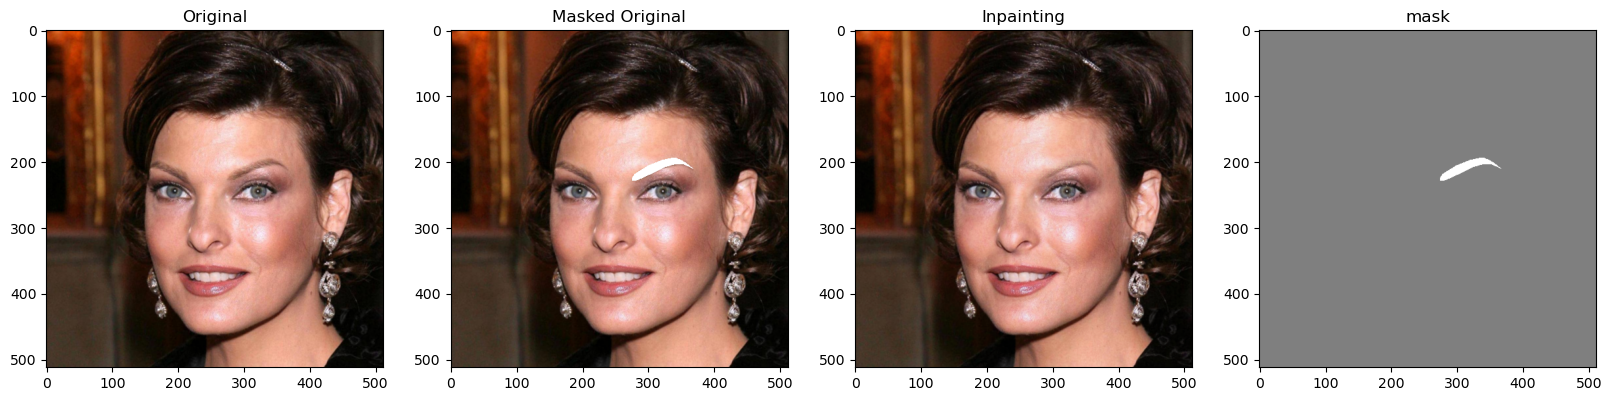

<Figure size 640x480 with 0 Axes>

In [16]:
import matplotlib.pyplot as plt
fig,axes = plt.subplots(1,4,figsize=(20,20))
model = InpaintGenerator()
model.eval()
model.load_state_dict(torch.load('./training_checkpoints/checkpoint_epoch_133.pth')['generator_state_dict'])
data = InpaintingData(args)
img, mask,filename = data[0]
masked_image = (img * (1 - mask).float()) + mask
masked_img = torch.cat((masked_image, mask), dim=0)
input = masked_img.unsqueeze(0)
output = model(input).detach()
original = tensor2im(img.unsqueeze(0))
mask = tensor2im(mask.unsqueeze(0))
masked_original = tensor2im(masked_image.unsqueeze(0))
inpainting = tensor2im(output)
print(filename)
plt.figure()
axes[0].imshow(original)
axes[0].set_title('Original')
axes[1].imshow(masked_original)
axes[1].set_title('Masked Original')
axes[2].imshow(inpainting)
axes[2].set_title('Inpainting')
axes[3].imshow(mask)
axes[3].set_title('mask')
plt.show()